## 1. Structure & Guidelines

The most important thing to do is define your problem statement (with your partner). This will be your nexus and will help you choose the dataset. Ideally this is the problem that you work on for the rest of the project. Since this is a big decision, you can change the problem statement and the dataset in the next assignment but no changes after that.

### Where to look for a dataset
There are too many sources for me to name all of them. **Kaggle** is the most popular. To search you can just use google or **Google Dataset Search** specifically. A lot of universities have their datasets available, like the one I use in my example below, which can be a great resource too. 


### EDA Study
Here are some mandatory material to help you get a basic understanding:
- https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
- https://www.youtube.com/watch?v=9m4n2xVzk9o

The sky is the limit with EDA, use this as a starting point and I expect you to go beyond. For instance I personally love this free book https://jakevdp.github.io/PythonDataScienceHandbook/ that dives deep into data science with python. <br>
This book is entirely in jupyter notebooks for even more code examples: https://allendowney.github.io/ElementsOfDataScience/



## 2. Assignment Questions/Tasks

1) Brainstorm & write down a problem statement
2)This analysis investigates the relationship between smartphone usage and work productivity. Specifically exploring whether increased screen time, social media usage, and sleep patterns influence an individual's productivity score. The dataset appears clean at first glance. The features align with the problem of analyzing smartphone usage and productivity. No obvious missing values or corrupted entries are visible in the first few rows, suggesting the dataset is well structured for analysis. The scatter plot suggests a slight negative relationship between phone usage and productivity. Individuals with higher daily phone hours tend to show slightly lower productivity scores, though the relationship does not appear extremely strong. Based on the exploratory analysis, screen time and sleep hours appear to have the strongest relationship with productivity. Next, I could build predictive models to determine whether smartphone usage can accurately predict productivity levels.

## 3. Exploratory Data Analysis

This is the same example from class. I have kept things basic and barebones here so this can serve as a springboard for your analyses. In each step I have added some questions you should ask to get insights into the dataset. The answers to these and other questions that you ask might be through more statistical analysis and visualizations!

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



### 1. Data Loading & Quick Overview

In [5]:
#Your dataset here
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [6]:
# Display first few rows
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


#### Questions to ponder: 

1. Does the data match your expectations or do you think you might need more information?
2. Do the columns/features align with your problem statement?
3. Any immediate signs of missing or corrupted data? 
the data looks good, no visible issues.

### 2. Shape & Features

In [7]:
# Shape : (rows, columns)
print(f"Dataset shape: {df.shape}")

# Display all column names
print("\nFeature Names:")
print(df.columns.tolist())

Dataset shape: (50000, 13)

Feature Names:
['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']


#### Questions to ponder: 

1. Is the data large enough for the analysis?
2. Are there any duplicate columns, or columns with similar information or ones that need re-naming? (I renamed some columns in my dataset below)
there are 50,000 observations which is suitable for my analysis. I renamed screen time hours to just screen time for renaming practice 

In [8]:
#Get unique target values
df['Gender'].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

### 3. Data Types & Missing Values

In [9]:
# understanding the datatypes
df.dtypes

User_ID                          str
Age                            int64
Gender                           str
Occupation                       str
Device_Type                      str
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

In [10]:
# Check missing values
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


#### Questions to ponder: 

- Should we drop or impute missing values?
- Could missing data be an insight in and of itself?
- no missing values

### 4. Summary Statistics & Outlier Detection

In [11]:
#Summary Stats
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


#### Question to ponder
- Did you expect outliers? 
- Which features have unusually high or low values? What do they tell us about the data?
- Are there any suspicious patterns or extreme outliers?
- Do we need to drop or transform these outliers?

In [12]:
df.dtypes

User_ID                          str
Age                            int64
Gender                           str
Occupation                       str
Device_Type                      str
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

In [13]:
# show top 20 most common sleep hours values (use correct column name and quotes)
df['Sleep_Hours'].value_counts().head(20)

Sleep_Hours
5.0    1069
8.3    1069
5.2    1069
6.2    1044
4.8    1043
8.4    1041
5.4    1040
7.7    1039
5.8    1035
6.3    1032
8.5    1030
7.3    1027
8.7    1027
6.4    1026
4.1    1024
5.6    1023
7.2    1021
4.2    1021
6.8    1011
8.6    1007
Name: count, dtype: int64

### 5. Univariate Analysis

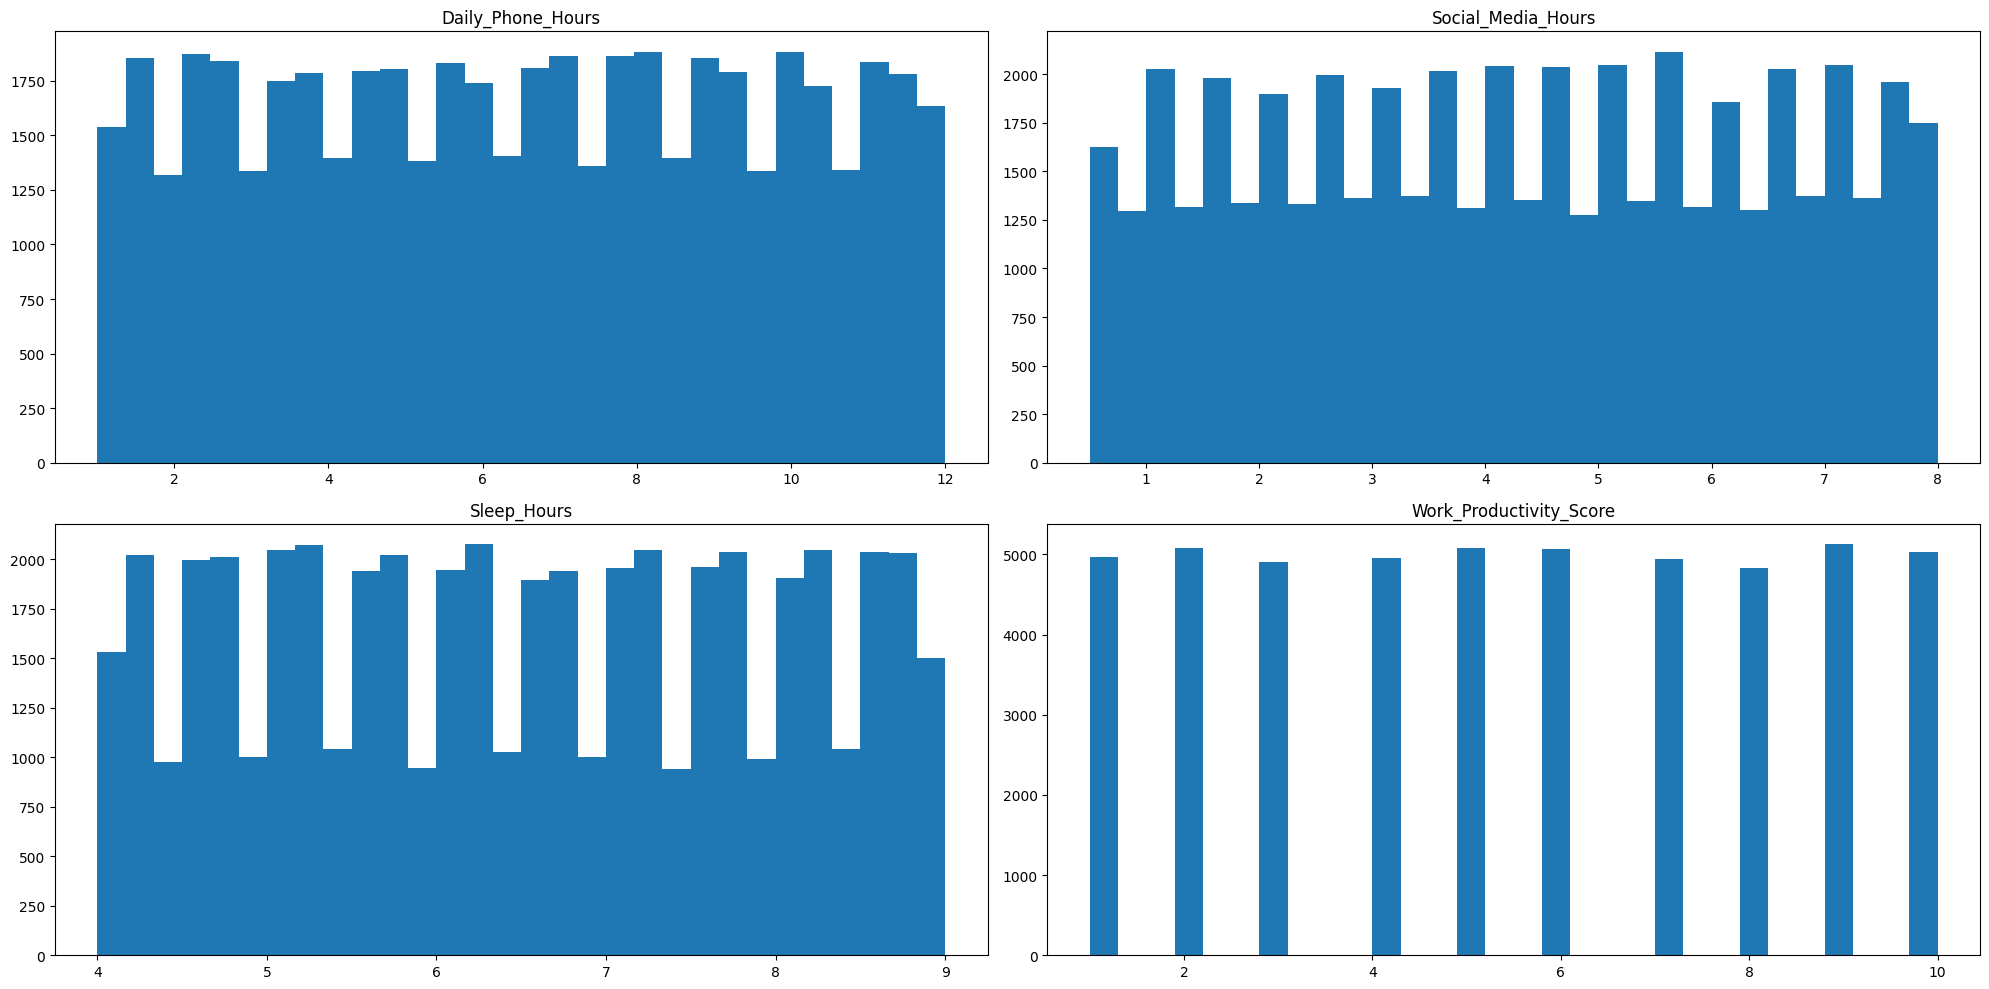

In [36]:
# Define features for visualization (Choosing the numerical features)
num_features = ['Daily_Phone_Hours', 'Social_Media_Hours', 'Sleep_Hours', 'Work_Productivity_Score']

fig, ax = plt.subplots(2, 2, figsize=(20,10))

for i, feature in enumerate(num_features):
    row, col = divmod(i, 2)
    ax[row, col].hist(df[feature], bins=30)
    ax[row, col].set_title(feature)

plt.tight_layout()
plt.show()

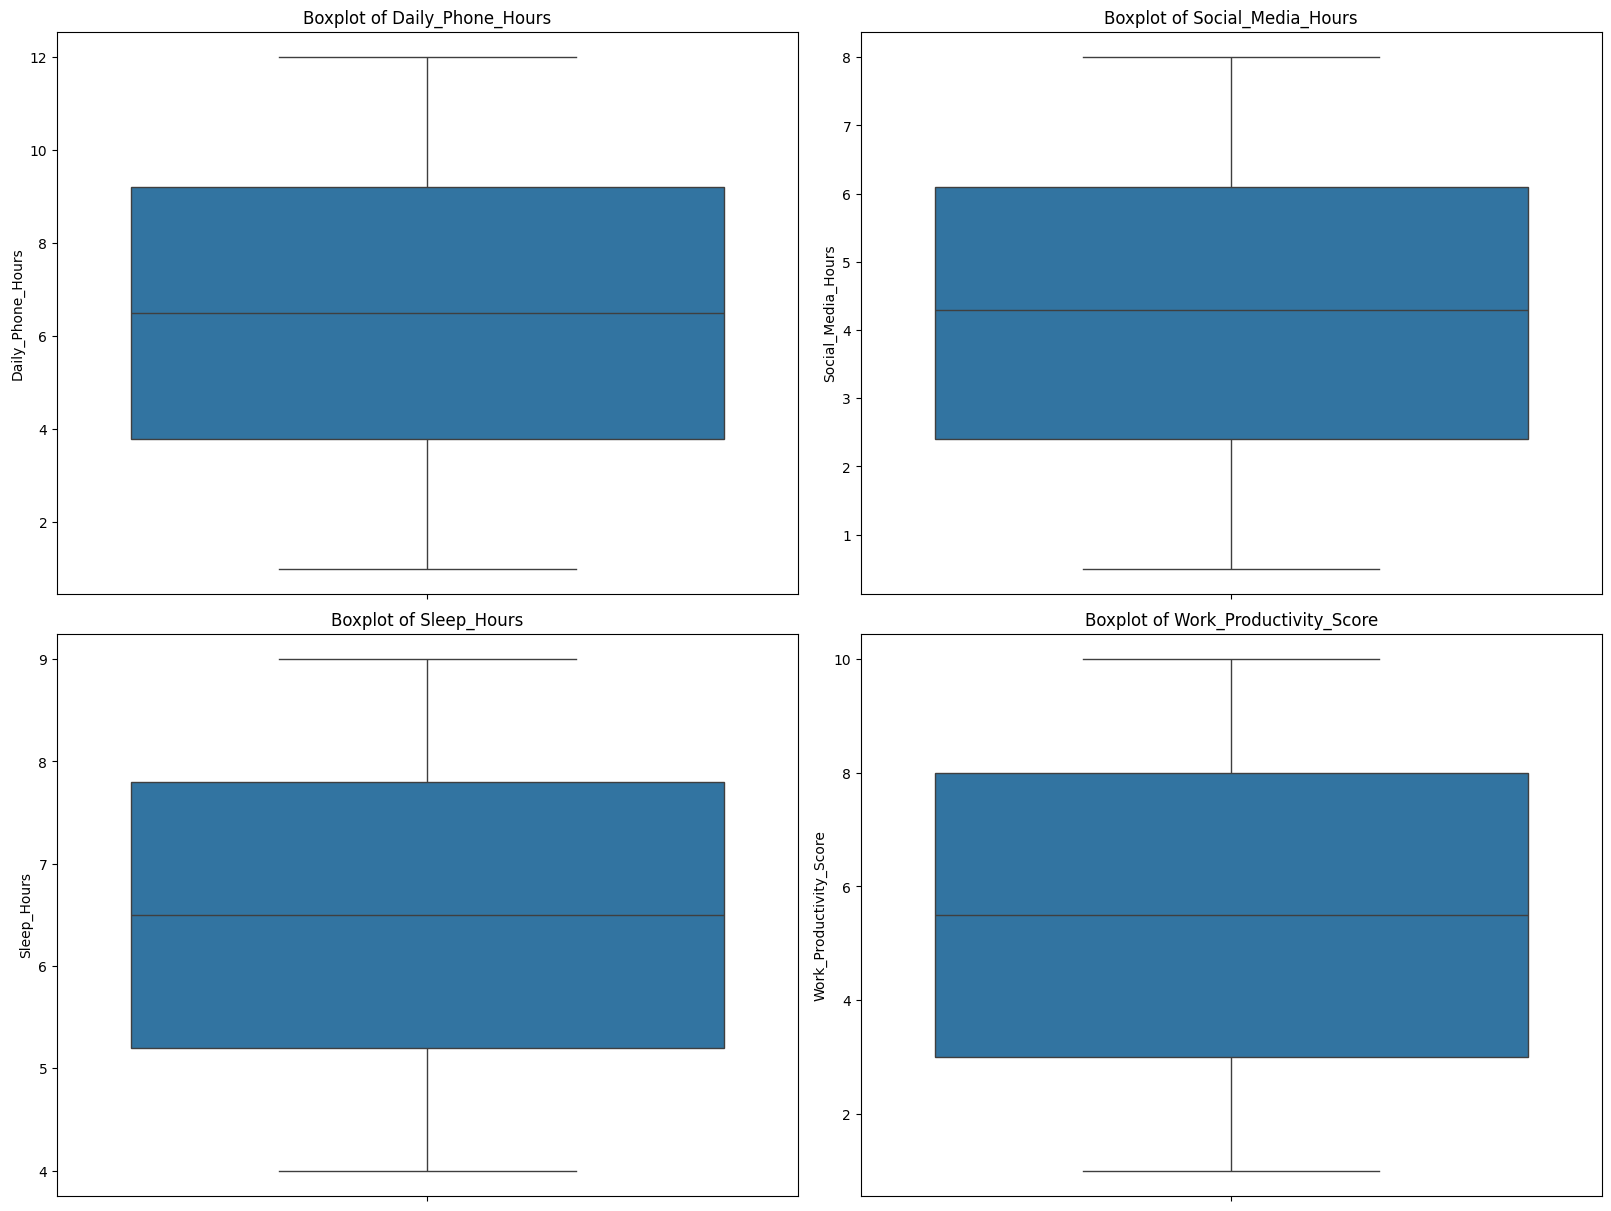

In [26]:
# Create boxplots for numerical variables
fig, ax = plt.subplots(3, 2, figsize=(18, 15))

for i, feature in enumerate(num_features):
    row, col = divmod(i, 2)
    sns.boxplot(y=df[feature], ax=ax[row, col])
    ax[row, col].set_title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


In [16]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='str')

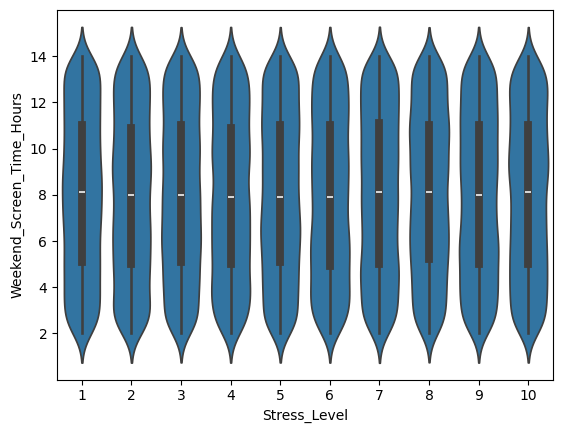

In [17]:
# Create violin plots for numerical variables
sns.violinplot(x='Stress_Level', y='Weekend_Screen_Time_Hours', data=df)
plt.show()


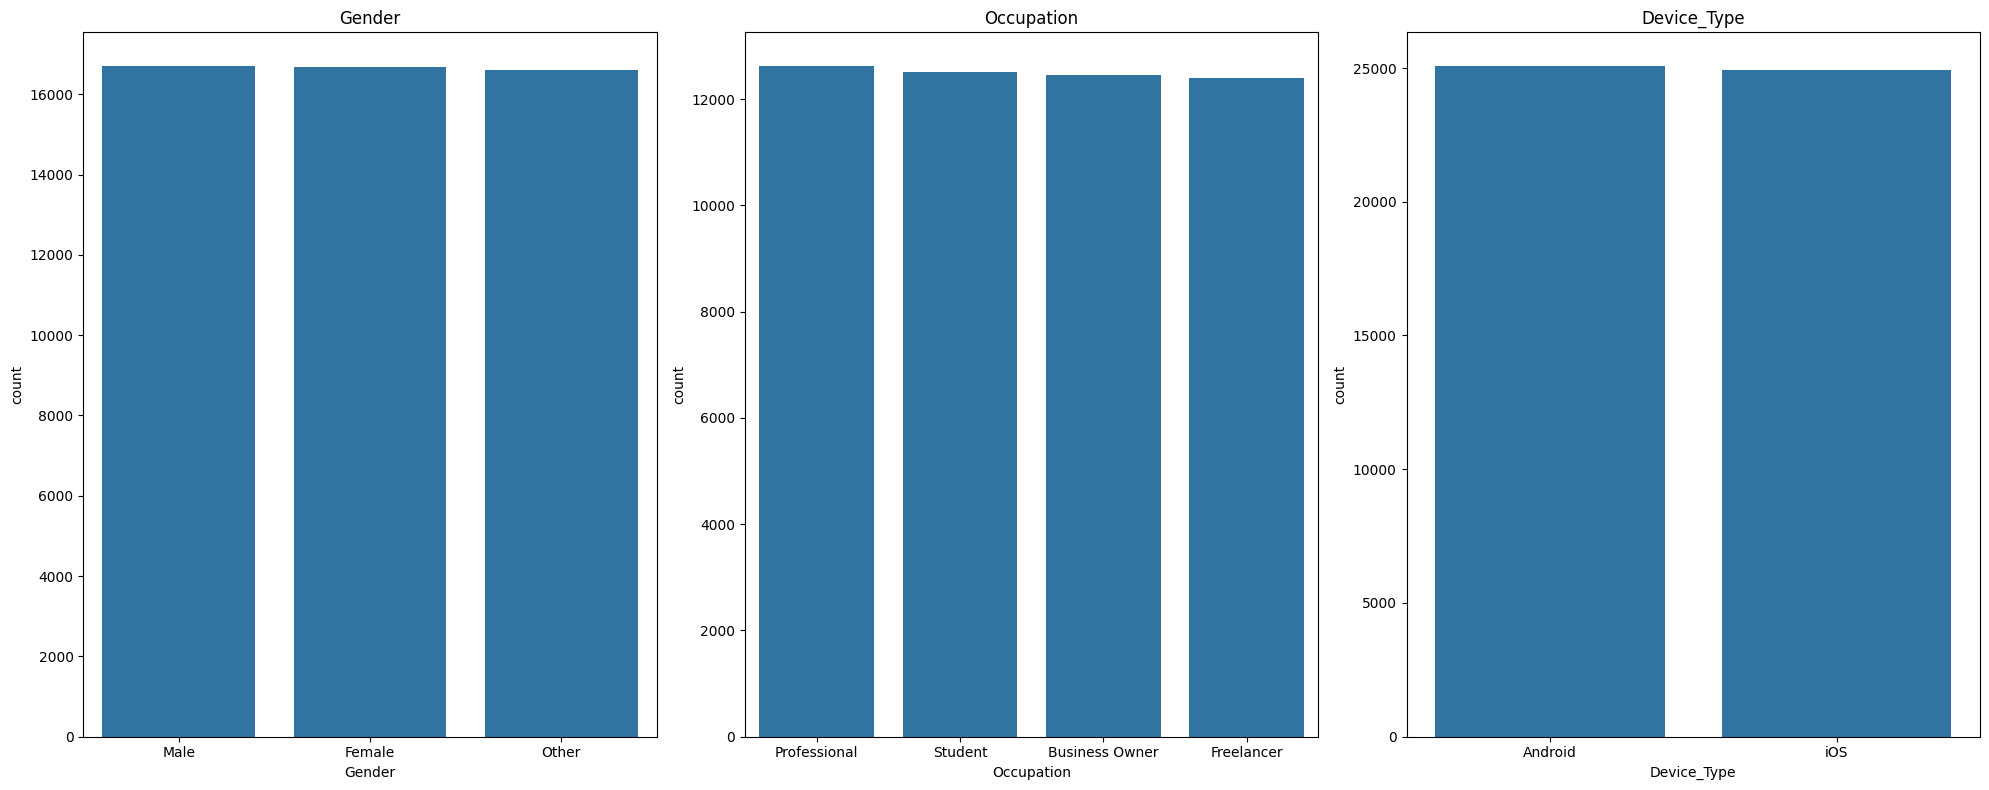

In [34]:
# Define categorical features for visualization
cat_features = ['Gender', 'Occupation', 'Device_Type']

fig, ax = plt.subplots(1, 3, figsize=(20,8))

for i, feature in enumerate(cat_features):
    sns.countplot(x=df[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

#### Questions to ponder:

- Are the numerical features skewed or roughly normal?
- Which categories dominate in each categorical feature? What does that tell you about each feature? 


### 6. Bivariate Analysis

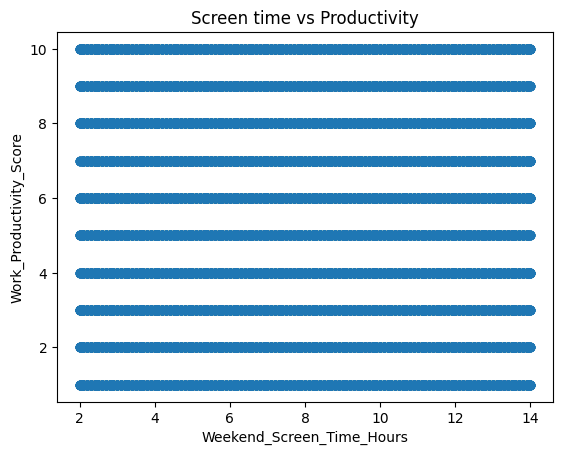

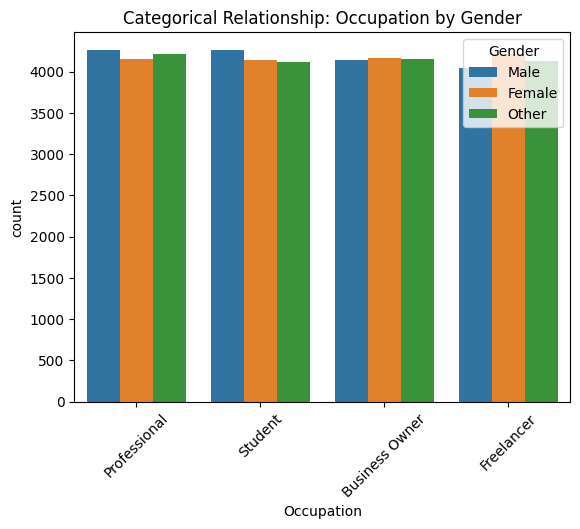

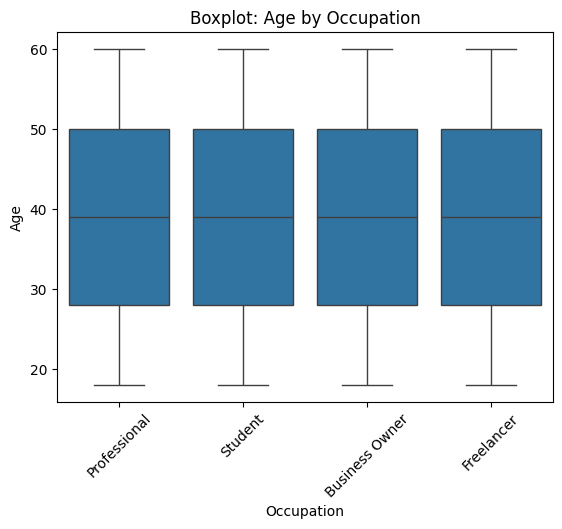

In [19]:
# Scatter plot for numerical vs. numerical
df.corr(numeric_only=True)
plt.figure()
plt.scatter(df['Weekend_Screen_Time_Hours'], df['Work_Productivity_Score'], alpha=0.5)
plt.xlabel("Weekend_Screen_Time_Hours")
plt.ylabel("Work_Productivity_Score")
plt.title("Screen time vs Productivity")
plt.show()

# Grouped bar plot for categorical vs. categorical
sns.countplot(data=df, x='Occupation', hue='Gender')
plt.title("Categorical Relationship: Occupation by Gender")
plt.xticks(rotation=45)
plt.show()

# Box plot for numerical vs. categorical
sns.boxplot(data=df, x='Occupation', y='Age')
plt.title("Boxplot: Age by Occupation")
plt.xticks(rotation=45)
plt.show()

#### Questions to ponder

- Which numerical features are correlated?
- Do certain categories strongly associate with higher or lower numerical values?
- Any visible clusters or patterns in scatter plots?

### 7. Multivariate Analysis

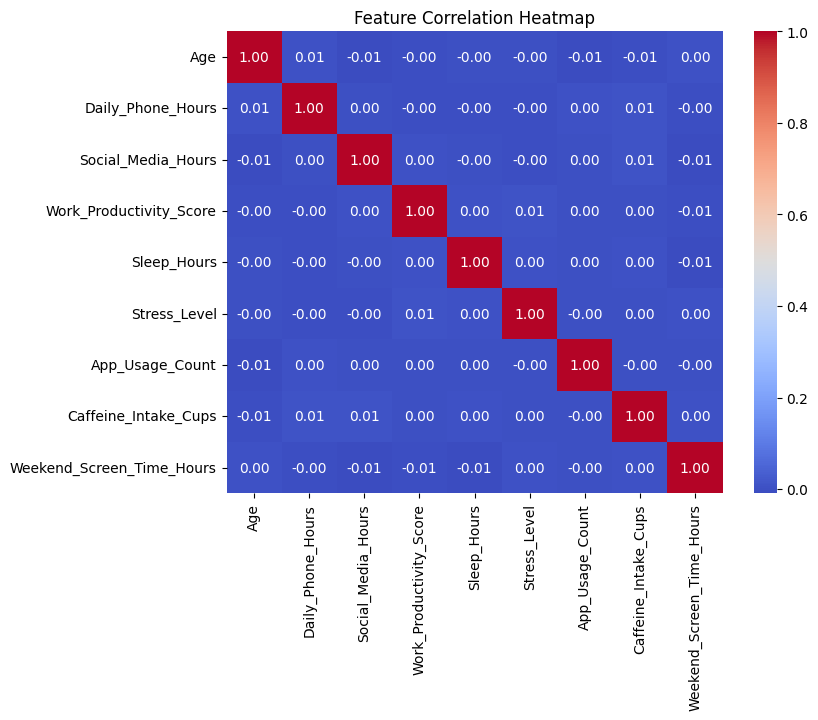

In [20]:
# Create a correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

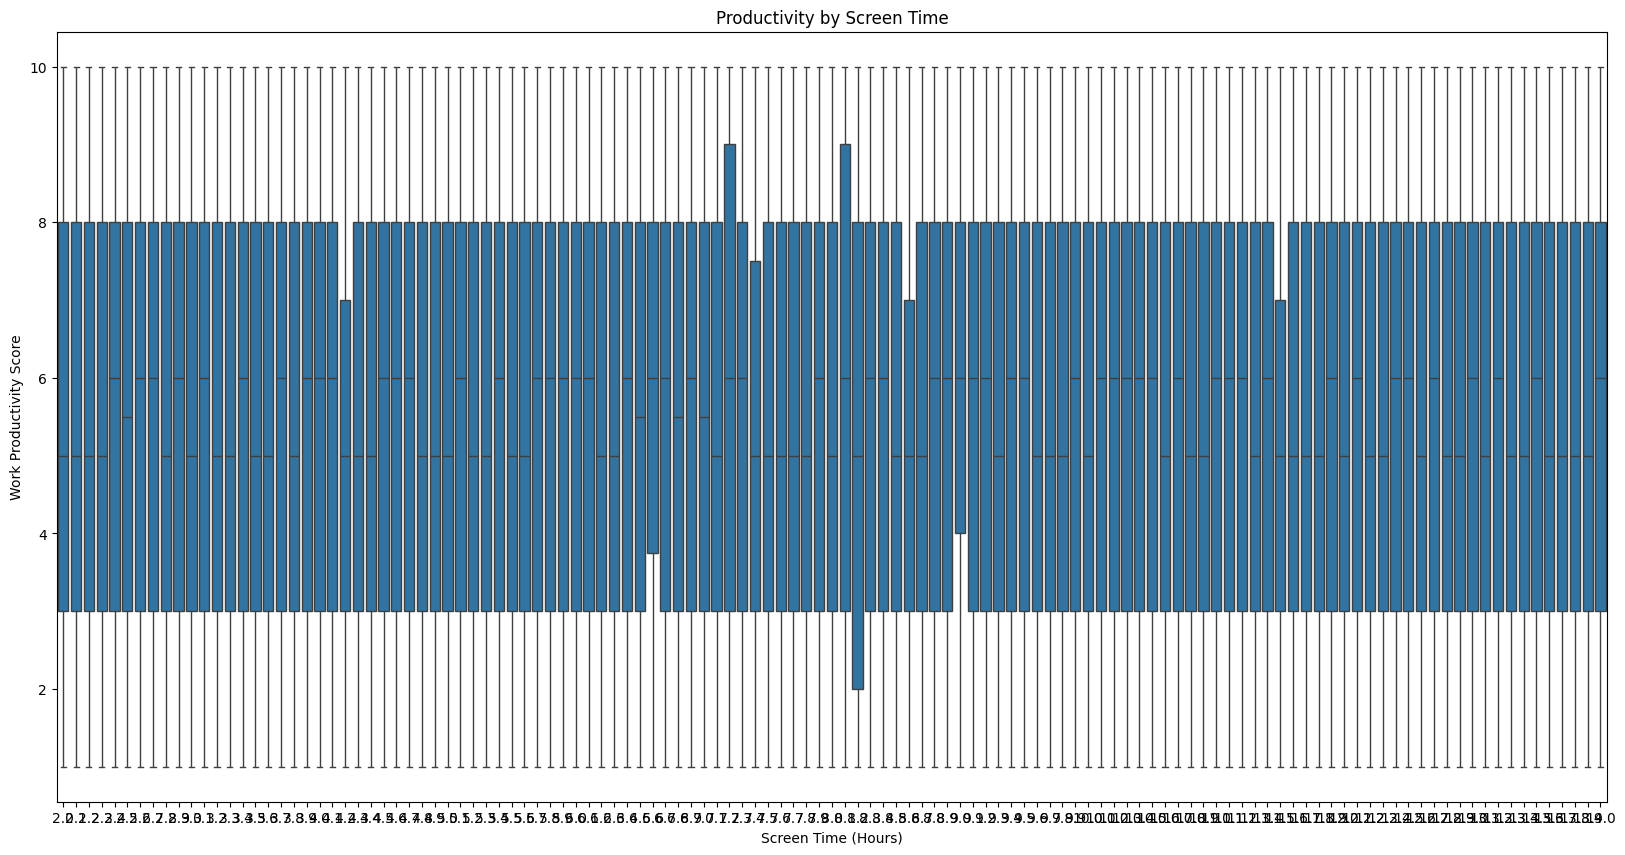

In [32]:
#productivity by screen time
plt.figure(figsize=(20,10))
sns.boxplot(data=df, x='Weekend_Screen_Time_Hours', y='Work_Productivity_Score')
plt.title("Productivity by Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Work Productivity Score")
plt.show()

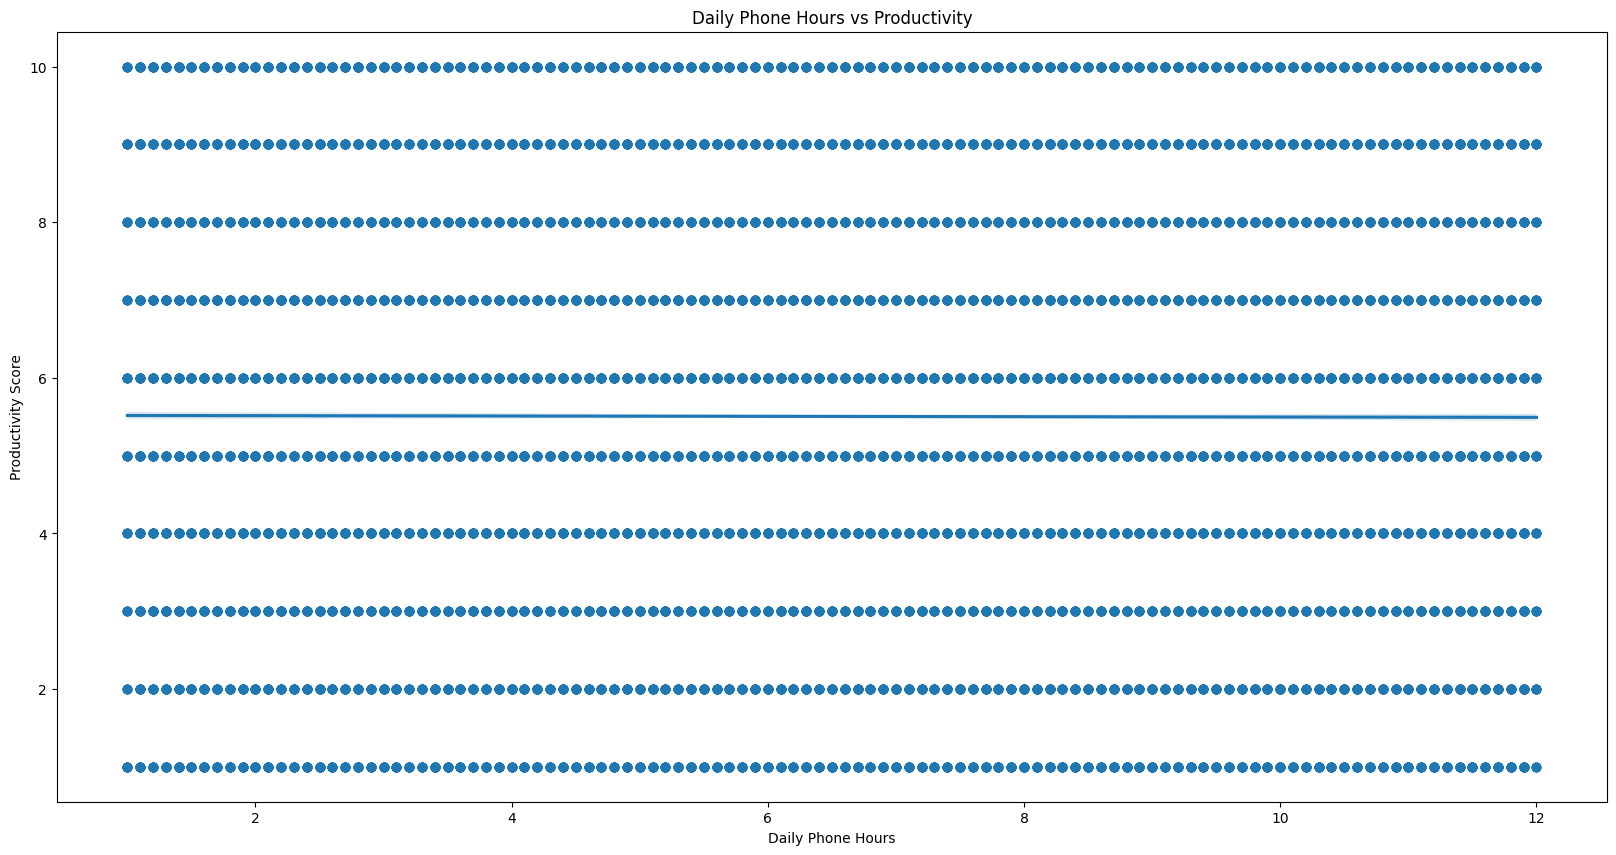

In [31]:
#insight plot: Daily Phone Hours vs Productivity
plt.figure(figsize=(20,10))
sns.regplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', data=df, scatter_kws={'alpha':0.3})
plt.title("Daily Phone Hours vs Productivity")
plt.xlabel("Daily Phone Hours")
plt.ylabel("Productivity Score")
plt.show()

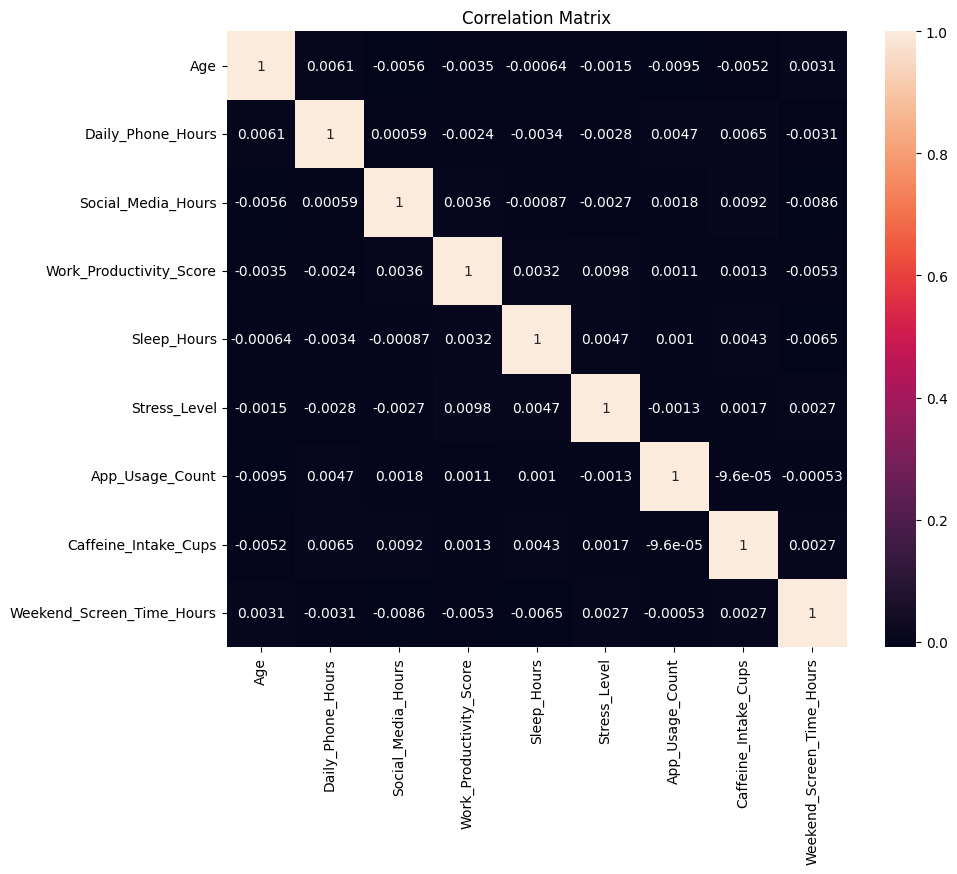

In [23]:
# Correlation heatmap for all numerical features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()


#### Questions to ponder

- Which features show strong correlation?
- Should we remove or combine highly correlated features?
- Are there surprising correlations that warrant deeper investigation?

### 8. Next Steps

- Which features appear most important for the problem?
- What data cleaning or transformation steps remain?
- How will these insights guide the next phase (modeling, reporting, or business decisions)?

## Resources
- Another amazing free book I have used : https://greenteapress.com/thinkstats/thinkstats.pdf
- https://towardsdatascience.com/data-science-101-life-cycle-of-a-data-science-project-86cbc4a2f7f0/